<a href="https://colab.research.google.com/github/qianloong1-source/ADALL_github/blob/main/Copy_of_CDA1C03_MOBA_WinPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/match.csv")

In [4]:
df.head()

,match_id,start_time,duration,tower_status_radiant,tower_status_dire,barracks_status_dire,barracks_status_radiant,first_blood_time,game_mode,radiant_win,negative_votes,positive_votes,cluster
0,0,1446750112,2375,1982,4,3,63,1,22,True,0,1,155
1,1,1446753078,2582,0,1846,63,0,221,22,False,0,2,154
2,2,1446764586,2716,256,1972,63,48,190,22,False,0,0,132
3,3,1446765723,3085,4,1924,51,3,40,22,False,0,0,191
4,4,1446796385,1887,2047,0,0,63,58,22,True,0,0,156


In [5]:
df.shape, df.columns

((50000, 13),
 Index(['match_id', 'start_time', 'duration', 'tower_status_radiant',
        'tower_status_dire', 'barracks_status_dire', 'barracks_status_radiant',
        'first_blood_time', 'game_mode', 'radiant_win', 'negative_votes',
        'positive_votes', 'cluster'],
       dtype='object'))

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   match_id                 50000 non-null  int64
 1   start_time               50000 non-null  int64
 2   duration                 50000 non-null  int64
 3   tower_status_radiant     50000 non-null  int64
 4   tower_status_dire        50000 non-null  int64
 5   barracks_status_dire     50000 non-null  int64
 6   barracks_status_radiant  50000 non-null  int64
 7   first_blood_time         50000 non-null  int64
 8   game_mode                50000 non-null  int64
 9   radiant_win              50000 non-null  bool 
 10  negative_votes           50000 non-null  int64
 11  positive_votes           50000 non-null  int64
 12  cluster                  50000 non-null  int64
dtypes: bool(1), int64(12)
memory usage: 4.6 MB


In [7]:
from google.colab import userdata
from openai import OpenAI

# Load key from Google Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')

client = OpenAI(
    api_key=api_key,
)

In [8]:
import pandas as pd
import numpy as np
from io import StringIO

# ---------------------------
# Generate a full dataset profile
# ---------------------------

buffer = StringIO()

# dtypes
buffer.write("=== DTYPES ===\n")
buffer.write(df.dtypes.to_string())
buffer.write("\n\n")

# numeric describe
buffer.write("=== NUMERIC DESCRIBE ===\n")
buffer.write(df.describe().to_string())
buffer.write("\n\n")

# categorical describe
buffer.write("=== CATEGORICAL DESCRIBE ===\n")
try:
    buffer.write(df.describe(include='object').to_string())
except:
    buffer.write("No categorical columns")
buffer.write("\n\n")

# null summary
buffer.write("=== NULL SUMMARY ===\n")
null_summary = (
    df.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda x: x["null_count"]/len(df))
)
buffer.write(null_summary.to_string())
buffer.write("\n\n")

# unique cardinality
buffer.write("=== UNIQUE VALUES PER COLUMN ===\n")
buffer.write(df.nunique().to_frame("unique_count").to_string())
buffer.write("\n\n")

# correlation matrix
buffer.write("=== CORRELATIONS (NUMERIC ONLY) ===\n")
buffer.write(df.corr(numeric_only=True).round(3).to_string())
buffer.write("\n\n")

# value counts for categoricals
buffer.write("=== VALUE COUNTS (TOP 20 PER CATEGORICAL COLUMN) ===\n")
cat_cols = df.select_dtypes(include='object').columns
if len(cat_cols) > 0:
    for col in cat_cols:
        buffer.write(f"\nColumn: {col}\n")
        vc = df[col].value_counts().head(20)
        buffer.write(vc.to_string())
        buffer.write("\n")
else:
    buffer.write("No categorical columns\n")
buffer.write("\n")

# --------- FIXED OUTLIER COMPUTATION (NO BOOLEANS) ---------
buffer.write("=== OUTLIER SUMMARY (IQR METHOD) ===\n")
num_cols = df.select_dtypes(include=['number']).columns  # exclude booleans
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR))).sum()
buffer.write(outliers.to_string())
buffer.write("\n\n")

# leakage scan: columns with all unique values
buffer.write("=== POSSIBLE LEAKAGE COLUMNS (UNIQUE FOR EACH ROW) ===\n")
leak_cols = df.columns[df.nunique() == len(df)]
buffer.write(str(list(leak_cols)))
buffer.write("\n\n")

# shape, duplicates, constant cols
buffer.write("=== SHAPE / DUPLICATES / CONSTANT COLUMNS ===\n")
dup_count = df.duplicated().sum()
constant_cols = df.columns[df.nunique() == 1].tolist()
buffer.write(f"Rows: {len(df)}, Columns: {df.shape[1]}\n")
buffer.write(f"Duplicate rows: {dup_count}\n")
buffer.write(f"Constant columns: {constant_cols}\n\n")

# Final text
payload_text = buffer.getvalue()

print(payload_text)

=== DTYPES ===
match_id                   int64
start_time                 int64
duration                   int64
tower_status_radiant       int64
tower_status_dire          int64
barracks_status_dire       int64
barracks_status_radiant    int64
first_blood_time           int64
game_mode                  int64
radiant_win                 bool
negative_votes             int64
positive_votes             int64
cluster                    int64

=== NUMERIC DESCRIBE ===
           match_id    start_time      duration  tower_status_radiant  tower_status_dire  barracks_status_dire  barracks_status_radiant  first_blood_time     game_mode  negative_votes  positive_votes       cluster
count  50000.000000  5.000000e+04  50000.000000          50000.000000       50000.000000          50000.000000              50000.00000      50000.000000  50000.000000    50000.000000    50000.000000  50000.000000
mean   24999.500000  1.447573e+09   2476.453500           1000.016440         935.250060             3

In [9]:
#sending to LLM API
response = client.responses.create(
    model="gpt-5-mini",
    instructions="""
You are an expert data scientist with extensive knowledge of tree-based models.
Use ONLY the information inside the dataset profile text.
Do NOT invent correlations, columns, or values.
If something is not in the dataset profile, state 'Not shown in profile'.
Always justify recommendations using reasoning trace based ONLY on the dataset profile.
""",
    input=f"""Dataset info: {payload_text}\n
    Context:
    I am doing an assignment and my persona is Game Operations / Matchmaking Analyst.
    My dataset is a MOBA/Dota-style match-level data (match.csv) and my target variable is radiant_win (win/loss).
    Can you generate the first draft for my Introduction/Context section?
    Please include:
    Business problem & why it matters
    Key beneficiary and persona
    JTBD statement
    Proposed modelling objective, target variable and possible predictors
    Please keep it non-gamer friendly (assume audience doesn't know Dota 2)
    """)
print(response.output_text)

Introduction / Context — Draft (for a non‑gamer audience)

Business problem & why it matters
- Problem statement: Build a predictive model that estimates the match outcome (a binary win/loss label) from match-level data. The immediate use case is to identify matches that are likely to produce imbalanced outcomes or unusual results.
- Why it matters: Accurate outcome prediction helps Game Operations and Matchmaking teams monitor fairness, evaluate matchmaking quality, detect systemic issues, and prioritize investigations or interventions. A reliable model supports operational decisions (e.g., tuning matchmaking parameters, flagging matches for review) and can reduce player dissatisfaction or churn.

Key beneficiary and persona
- Primary beneficiary: Game Operations / Matchmaking teams.
- Persona (provided): Matchmaking Analyst — someone responsible for monitoring match outcomes and improving the quality and fairness of pairings.

Jobs‑To‑Be‑Done (JTBD) statement
- When monitoring live a

In [10]:
#generate a preview of ten rows as text first, so that we can use it for sending to LLM API later.
data_preview = df.head(10).to_string()
print(data_preview)

   match_id  start_time  duration  tower_status_radiant  tower_status_dire  barracks_status_dire  barracks_status_radiant  first_blood_time  game_mode  radiant_win  negative_votes  positive_votes  cluster
0         0  1446750112      2375                  1982                  4                     3                       63                 1         22         True               0               1      155
1         1  1446753078      2582                     0               1846                    63                        0               221         22        False               0               2      154
2         2  1446764586      2716                   256               1972                    63                       48               190         22        False               0               0      132
3         3  1446765723      3085                     4               1924                    51                        3                40         22        False               0 

In [11]:
#sending to LLM API
response = client.responses.create(
    model="gpt-5-mini",
    instructions="""
You are an expert data scientist with extensive knowledge of tree-based models.
Use ONLY the information inside the dataset profile text.
Do NOT invent correlations, columns, or values.
If something is not in the dataset profile, state 'Not shown in profile'.
Always justify recommendations using reasoning trace based ONLY on the dataset profile.
""",
    input=f"""Dataset info: {data_preview}\n
    Context:
    I am doing an assignment and my persona is Game Operations / Matchmaking Analyst.
    My dataset is a MOBA/Dota-style match-level data (match.csv) and my target variable is radiant_win (win/loss).
    Can you generate the first draft for my Introduction/Context section?
    Please include:
    Business problem & why it matters
    Key beneficiary and persona
    JTBD statement
    Proposed modelling objective, target variable and possible predictors
    Please keep it non-gamer friendly (assume audience doesn't know Dota 2)
    """)
print(response.output_text)

Introduction / Context (first draft)

Business problem and why it matters
- Problem statement: Build a model to predict match outcome (radiant_win) from features available in the match-level dataset.
- Why it matters: Predicting match outcomes can help Game Operations and Matchmaking teams (the primary operators of multiplayer game systems) understand which match-level signals are associated with wins and losses, evaluate match balance, and prioritize investigations into unexpected results or systemic issues. The dataset contains match-level metadata and final-state indicators that can be used to produce an actionable classifier of match result.

Key beneficiary and persona
- Primary beneficiary: Game Operations / Matchmaking team (your persona).
- Role / need: As a Matchmaking Analyst, you need reliable, data-driven signals about match outcomes to support matchmaking policy tuning, monitoring for fairness or exploits, and informing operational decisions.

Job To Be Done (JTBD) stateme

In [12]:
# look for likely target columns
candidates = [c for c in df.columns if "win" in c.lower() or "outcome" in c.lower() or "winner" in c.lower()]
candidates

['radiant_win']

In [13]:
TARGET_COL = "radiant_win"
df[TARGET_COL].value_counts(dropna=False), df[TARGET_COL].value_counts(normalize=True, dropna=False)

(radiant_win
 True     25943
 False    24057
 Name: count, dtype: int64,
 radiant_win
 True     0.51886
 False    0.48114
 Name: proportion, dtype: float64)

In [14]:
# missing values
missing = df.isna().sum().sort_values(ascending=False)
missing.head(20)

,0
match_id,0
start_time,0
duration,0
tower_status_radiant,0
tower_status_dire,0
barracks_status_dire,0
barracks_status_radiant,0
first_blood_time,0
game_mode,0
radiant_win,0


In [15]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe(include="all").T.head(30)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
match_id,50000.0,NaN,NaN,NaN,24999.5,14433.901067,0.0,12499.75,24999.5,37499.25,49999.0
start_time,50000.0,NaN,NaN,NaN,1447573116.80818,148527.024156,1446750112.0,1447456289.5,1447577193.0,1447700343.25,1447829215.0
duration,50000.0,NaN,NaN,NaN,2476.4535,634.631261,59.0,2029.0,2415.0,2872.0,16037.0
tower_status_radiant,50000.0,NaN,NaN,NaN,1000.01644,948.211846,0.0,0.0,1536.0,1974.0,2047.0
tower_status_dire,50000.0,NaN,NaN,NaN,935.25006,937.974714,0.0,0.0,384.0,1972.0,2047.0
barracks_status_dire,50000.0,NaN,NaN,NaN,34.52946,29.209672,0.0,0.0,51.0,63.0,63.0
barracks_status_radiant,50000.0,NaN,NaN,NaN,34.77526,29.73214,0.0,0.0,51.0,63.0,63.0
first_blood_time,50000.0,NaN,NaN,NaN,93.82552,92.648332,0.0,9.0,77.0,144.0,831.0
game_mode,50000.0,NaN,NaN,NaN,21.468,3.218258,2.0,22.0,22.0,22.0,22.0
radiant_win,50000,2,True,25943,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
[id_col for id_col in df.columns if "id" in id_col.lower()]

['match_id']

In [18]:
high_card = df.nunique().sort_values(ascending=False)
high_card.head(20)

,0
match_id,50000
start_time,46836
duration,3573
first_blood_time,550
tower_status_dire,128
tower_status_radiant,127
barracks_status_radiant,51
barracks_status_dire,48
cluster,32
positive_votes,32


## Clean pipeline

In [19]:
## Convert target True/False → 0/1
TARGET_COL = "radiant_win"
df[TARGET_COL] = df[TARGET_COL].astype(int)

df[TARGET_COL].value_counts(), df[TARGET_COL].value_counts(normalize=True)

(radiant_win
 1    25943
 0    24057
 Name: count, dtype: int64,
 radiant_win
 1    0.51886
 0    0.48114
 Name: proportion, dtype: float64)

In [20]:
# Check missing values
df.isna().sum().sort_values(ascending=False)

,0
match_id,0
start_time,0
duration,0
tower_status_radiant,0
tower_status_dire,0
barracks_status_dire,0
barracks_status_radiant,0
first_blood_time,0
game_mode,0
radiant_win,0


In [21]:
# Choose features (drop ID/time)
drop_cols = ["match_id", "start_time"]

In [22]:
# create X and y:
X = df.drop(columns=drop_cols + [TARGET_COL])
y = df[TARGET_COL]

X.shape, y.shape, X.columns

((50000, 10),
 (50000,),
 Index(['duration', 'tower_status_radiant', 'tower_status_dire',
        'barracks_status_dire', 'barracks_status_radiant', 'first_blood_time',
        'game_mode', 'negative_votes', 'positive_votes', 'cluster'],
       dtype='object'))

In [23]:
# Split train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((40000, 10), (10000, 10))

In [24]:
# Baseline model (Logistic Regression)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

logreg_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000))])

In [25]:
# Evaluate baseline (accuracy + ROC-AUC)
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred = logreg_model.predict(X_test)
y_proba = logreg_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Accuracy: 0.9918
ROC-AUC: 0.9998215450163812
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4811
           1       0.99      0.99      0.99      5189

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [26]:
# Fix Leakage (IMPORTANT!!!)
## Check correlation of leakage features
leak_cols = [
    "tower_status_radiant", "tower_status_dire",
    "barracks_status_radiant", "barracks_status_dire"
]

df[[TARGET_COL] + leak_cols].corr()

,radiant_win,tower_status_radiant,tower_status_dire,barracks_status_radiant,barracks_status_dire
radiant_win,1.000000,0.969061,-0.964169,0.873323,-0.837214
tower_status_radiant,0.969061,1.000000,-0.940027,0.919608,-0.835995
tower_status_dire,-0.964169,-0.940027,1.000000,-0.862742,0.891254
barracks_status_radiant,0.873323,0.919608,-0.862742,1.000000,-0.777820
barracks_status_dire,-0.837214,-0.835995,0.891254,-0.777820,1.000000


In [27]:
# Build a clean feature set (drop leakage columns)
drop_cols = ["match_id", "start_time"] + leak_cols

X2 = df.drop(columns=drop_cols + [TARGET_COL])
y2 = df[TARGET_COL]

X2.shape, X2.columns

((50000, 6),
 Index(['duration', 'first_blood_time', 'game_mode', 'negative_votes',
        'positive_votes', 'cluster'],
       dtype='object'))

In [28]:
# Split again
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

In [29]:
# Retrain logistic regression on clean dataset
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg2 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

logreg2.fit(X2_train, y2_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=2000))])

In [30]:
# Re-evaluation
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y2_pred = logreg2.predict(X2_test)
y2_proba = logreg2.predict_proba(X2_test)[:, 1]

print("Accuracy:", accuracy_score(y2_test, y2_pred))
print("ROC-AUC:", roc_auc_score(y2_test, y2_proba))
print(classification_report(y2_test, y2_pred))

Accuracy: 0.5308
ROC-AUC: 0.547429929780868
              precision    recall  f1-score   support

           0       0.52      0.31      0.39      4811
           1       0.54      0.73      0.62      5189

    accuracy                           0.53     10000
   macro avg       0.53      0.52      0.50     10000
weighted avg       0.53      0.53      0.51     10000



In [31]:
# Train a Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X2_train, y2_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [32]:
# Evaluate Random Forest
rf_pred = rf.predict(X2_test)
rf_proba = rf.predict_proba(X2_test)[:, 1]

print("RF Accuracy:", accuracy_score(y2_test, rf_pred))
print("RF ROC-AUC:", roc_auc_score(y2_test, rf_proba))
print(classification_report(y2_test, rf_pred))

RF Accuracy: 0.5151
RF ROC-AUC: 0.5226517256917373
              precision    recall  f1-score   support

           0       0.50      0.47      0.48      4811
           1       0.53      0.56      0.54      5189

    accuracy                           0.52     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.52      0.51     10000



In [33]:
# Bar chart comparison (Accuracy + ROC-AUC)
import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression (Clean)", "Random Forest (Clean)"],
    "Accuracy": [accuracy_score(y2_test, y2_pred), accuracy_score(y2_test, rf_pred)],
    "ROC-AUC": [roc_auc_score(y2_test, y2_proba), roc_auc_score(y2_test, rf_proba)]
})

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression (Clean),0.5308,0.547430
1,Random Forest (Clean),0.5151,0.522652


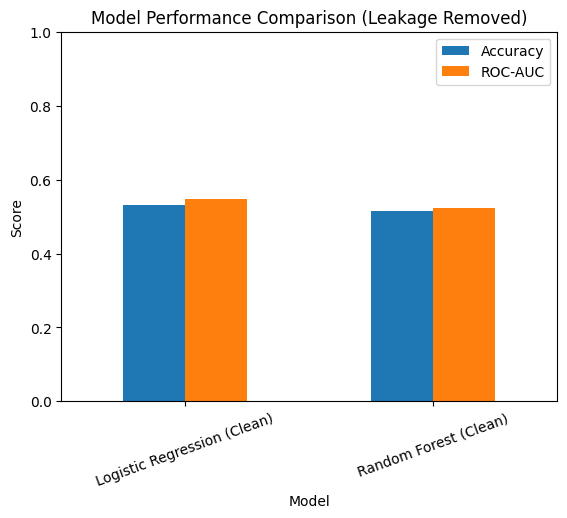

In [34]:
results.set_index("Model")[["Accuracy", "ROC-AUC"]].plot(kind="bar")
plt.title("Model Performance Comparison (Leakage Removed)")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

In [35]:
# Feature Importance (Random Forest)
import pandas as pd

feat_imp = pd.DataFrame({
    "feature": X2.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.head(10)

,feature,importance
0,duration,0.534946
1,first_blood_time,0.338811
5,cluster,0.114708
2,game_mode,0.004745
4,positive_votes,0.004063
3,negative_votes,0.002726


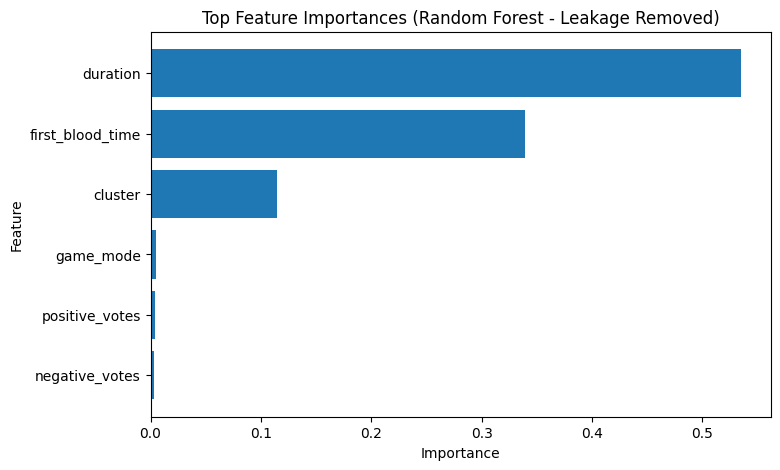

In [36]:
# Plot Feature Importance (Top 10)
import matplotlib.pyplot as plt

top_n = 10
top_feat = feat_imp.head(top_n).sort_values("importance")

plt.figure(figsize=(8,5))
plt.barh(top_feat["feature"], top_feat["importance"])
plt.title("Top Feature Importances (Random Forest - Leakage Removed)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [37]:
# Permutation Importance
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X2_test, y2_test, n_repeats=10, random_state=42)

perm_imp = pd.DataFrame({
    "feature": X2.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

perm_imp.head(10)

,feature,importance_mean,importance_std
0,duration,0.01303,0.004316
5,cluster,0.00643,0.003492
2,game_mode,0.00111,0.000784
4,positive_votes,0.00093,0.000780
1,first_blood_time,-0.00022,0.004324
3,negative_votes,-0.00054,0.000364


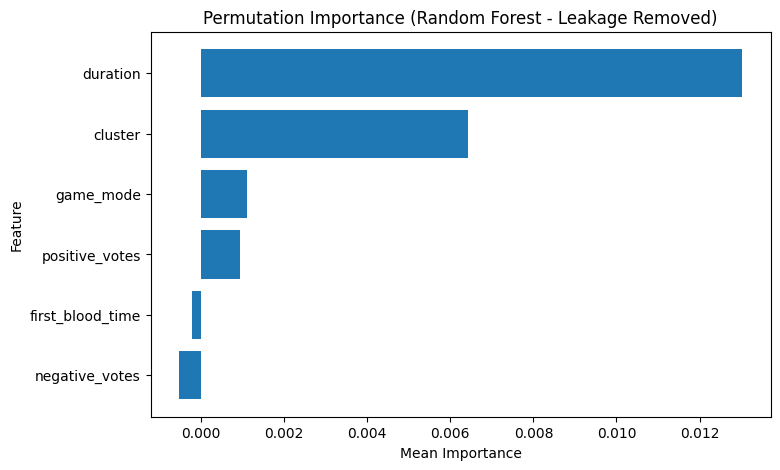

In [38]:
top_perm = perm_imp.head(10).sort_values("importance_mean")

plt.figure(figsize=(8,5))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.title("Permutation Importance (Random Forest - Leakage Removed)")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.show()

In [39]:
# Build an “EARLY MATCH MODEL” feature set
early_drop = ["duration"]  # remove near-leakage / post-match info

X3 = X2.drop(columns=early_drop)
y3 = y2

X3.shape, X3.columns

((50000, 5),
 Index(['first_blood_time', 'game_mode', 'negative_votes', 'positive_votes',
        'cluster'],
       dtype='object'))

In [40]:
# Train-test split again
from sklearn.model_selection import train_test_split

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

In [41]:
# Train Logistic Regression + Random Forest again
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg3 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])
logreg3.fit(X3_train, y3_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=2000))])

In [42]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf3 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)
rf3.fit(X3_train, y3_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [43]:
# Evaluate both
from sklearn.metrics import accuracy_score, roc_auc_score

# Logistic
log3_pred = logreg3.predict(X3_test)
log3_proba = logreg3.predict_proba(X3_test)[:, 1]

# RF
rf3_pred = rf3.predict(X3_test)
rf3_proba = rf3.predict_proba(X3_test)[:, 1]

print("LogReg (Early) Accuracy:", accuracy_score(y3_test, log3_pred))
print("LogReg (Early) ROC-AUC:", roc_auc_score(y3_test, log3_proba))

print("RF (Early) Accuracy:", accuracy_score(y3_test, rf3_pred))
print("RF (Early) ROC-AUC:", roc_auc_score(y3_test, rf3_proba))

LogReg (Early) Accuracy: 0.519
LogReg (Early) ROC-AUC: 0.501496758628599
RF (Early) Accuracy: 0.499
RF (Early) ROC-AUC: 0.4976151924916397


In [44]:
# Feature importance for early model
import pandas as pd

feat_imp3 = pd.DataFrame({
    "feature": X3.columns,
    "importance": rf3.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp3.head(10)

,feature,importance
0,first_blood_time,0.814159
4,cluster,0.161905
3,positive_votes,0.010560
2,negative_votes,0.007161
1,game_mode,0.006215


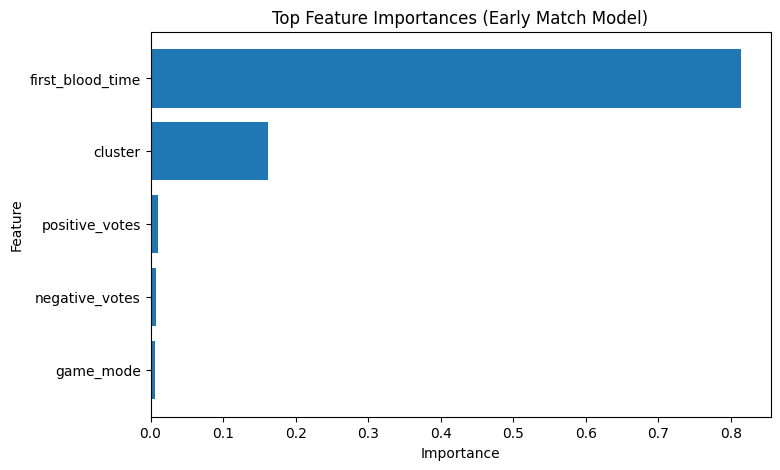

In [45]:
import matplotlib.pyplot as plt

top_n = 10
top_feat3 = feat_imp3.head(top_n).sort_values("importance")

plt.figure(figsize=(8,5))
plt.barh(top_feat3["feature"], top_feat3["importance"])
plt.title("Top Feature Importances (Early Match Model)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [46]:
num_cols = df.select_dtypes(include=["number"]).columns
num_cols = [c for c in num_cols if c not in ["match_id", "start_time"]]  # exclude IDs

outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, outliers, outliers/len(df)])

outliers_df = pd.DataFrame(outlier_summary, columns=["column", "outlier_count", "outlier_pct"])
outliers_df.sort_values("outlier_count", ascending=False)

,column,outlier_count,outlier_pct
10,cluster,2326,0.04652
6,game_mode,1330,0.02660
5,first_blood_time,915,0.01830
0,duration,647,0.01294
9,positive_votes,548,0.01096
8,negative_votes,329,0.00658
1,tower_status_radiant,0,0.00000
2,tower_status_dire,0,0.00000
4,barracks_status_radiant,0,0.00000
3,barracks_status_dire,0,0.00000


In [47]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")

auc_scores = cross_val_score(rf_cv, X2, y2, cv=cv, scoring="roc_auc")
print("5-fold CV ROC-AUC mean:", np.mean(auc_scores))
print("5-fold CV ROC-AUC std :", np.std(auc_scores))

5-fold CV ROC-AUC mean: 0.5168129982833055
5-fold CV ROC-AUC std : 0.0030475831451856313
